# **Arabic AI or Human Text Detection Using NLP Techniques**


Group member names:

joud alrefaei

Rafa'a alharbi

Nada alrashidi

Renad almatrafi

Section:F06

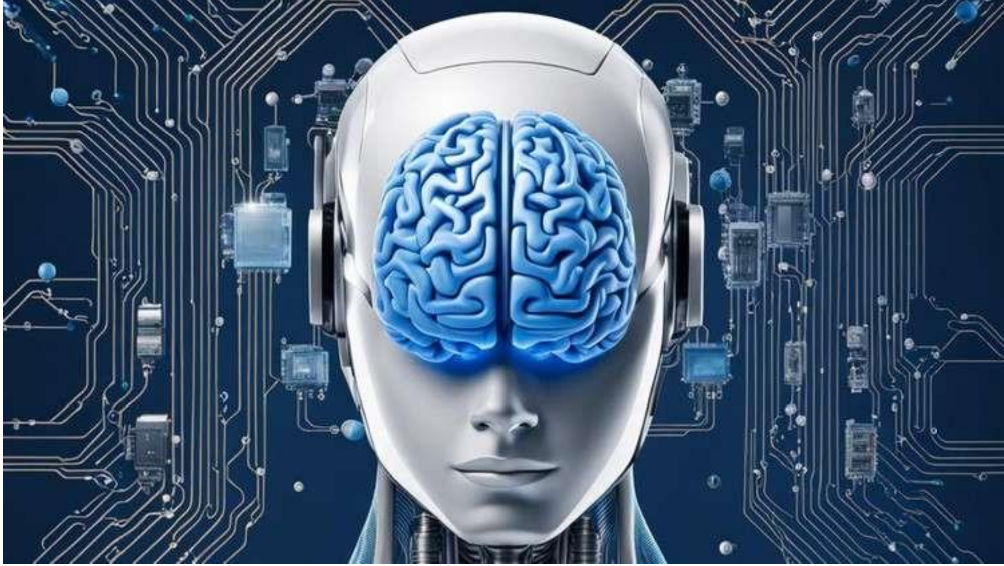

Problem Statement

With the increasing use of AI tools to generate Arabic text, it has become difficult to distinguish between human-written and AI-generated content. This project aims to build and compare multiple NLP models to classify Arabic text as either human-written or AI-generated.

 Project Objectives

- Preprocess Arabic text using normalization, cleaning, tokenization, stopword removal, stemming, and lemmatization.
- Extract textual features using BoW, TF-IDF, and Word2Vec.
- Train traditional machine learning models such as Naive Bayes, Logistic Regression, and SVM.
- Fine-tune AraBERT for Arabic AI-generated text detection.
- Compare model performance using Accuracy, F1-score, Precision, Recall, and Confusion Matrix.

# **📚  Import Libraries**

In [ ]:
!pip install transformers accelerate -q
!pip install nltk tashaphyne pandas
!pip install gensim
from gensim.models import Word2Vec

In [ ]:
#imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import nltk
import string
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import nltk
nltk.download('stopwords')
from nltk.stem.isri import ISRIStemmer
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from tashaphyne.stemming import ArabicLightStemmer
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from tqdm import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

!pip install transformers accelerate -q

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



# **📂Load Dataset**

In [ ]:
df = pd.read_csv('ALHD_balanced_10percent.csv')
df.head()

,source,document_id,text,label,generator,category,subcategory,token_count,text_for_arabert_base,text_for_arabert_large,text_for_araelectra
0,ANAD,34015,عجز الميزانية الأمريكية يرتفع إلى 399 مليار دو...,0,HUMAN,aleqt.com,Economy,335,عجز ال+ ميزاني +ة ال+ أمريكي +ة يرتفع إلى 399 ...,عجز ال+ ميزاني +ة ال+ أمريكي +ة يرتفع إلى 399 ...,عجز الميزانية الأمريكية يرتفع إلى 399 مليار دو...
1,ANAD,34015,زيادة عجز الميزانية الأمريكية إلى 399 مليار دو...,1,GPT-3.5-T,aleqt.com,Economy,380,زياد +ة عجز ال+ ميزاني +ة ال+ أمريكي +ة إلى 39...,زياد +ة عجز ال+ ميزاني +ة ال+ أمريكي +ة إلى 39...,زيادة عجز الميزانية الأمريكية إلى 399 مليار دو...
2,ANAD,34051,الاسترليني يهبط أمام الدولار واليورو وسط شكوك ...,0,HUMAN,aleqt.com,Economy,234,ال+ إسترليني يهبط أمام ال+ دولار و+ ال+ يورو و...,ال+ إسترليني يهبط أمام ال+ دولار و+ ال+ يورو و...,الاسترليني يهبط أمام الدولار واليورو وسط شكوك ...
3,ANAD,34051,تراجع الجنيه الاسترليني اليوم الاثنين أمام الد...,1,GPT-3.5-T,aleqt.com,Economy,214,تراجع ال+ جنيه ال+ إسترليني ال+ يوم ال+ اثنين ...,تراجع ال+ جنيه ال+ إسترليني ال+ يوم ال+ اثنين ...,تراجع الجنيه الاسترليني اليوم الاثنين أمام الد...
4,ANAD,34055,الحديدة.. قصف حوثي يحرق طعام الجياع داخل مطاحن...,0,HUMAN,alarabiya.net,Politics,521,ال+ حديد +ة . . قصف حوثي يحرق طعام ال+ جياع دا...,ال+ حديد +ة . . قصف حوثي يحرق طعام ال+ جياع دا...,الحديدة . . قصف حوثي يحرق طعام الجياع داخل مطا...


# **🔍  Explore Dataset**

In [ ]:
# Dataset shape
print("Dataset Shape:", df.shape)

Dataset Shape: (20268, 11)


In [ ]:
# Column names
print("Columns:")
print(df.columns)

Columns:
Index(['source', 'document_id', 'text', 'label', 'generator', 'category',
       'subcategory', 'token_count', 'text_for_arabert_base',
       'text_for_arabert_large', 'text_for_araelectra'],
      dtype='object')


# 📚 Dataset Description

The dataset used in this project is the **ALHD (Arabic LLM-Human Dataset)**, which was introduced in the research paper:

**“ALHD: Arabic LLM-Human Dataset for Detecting AI-Generated Arabic Text”**

The dataset is designed for distinguishing between Human-written Arabic text and LLM-generated Arabic text.

⚖️ The dataset used in this project is balanced and contains:

* 10,134 Human-written texts
* 10,134 LLM-generated texts

📊 Total samples:

* 20,268 text samples

Each sample consists of:

* 📝 **Text:** Arabic text content
* 🏷️ **Label:** Classification label

  * 0 → Human-written text
  * 1 → LLM-generated text

The dataset includes different types of Arabic text and was divided into training, development, and testing sets for model training and evaluation.


# 🏷️ Check Class Distribution

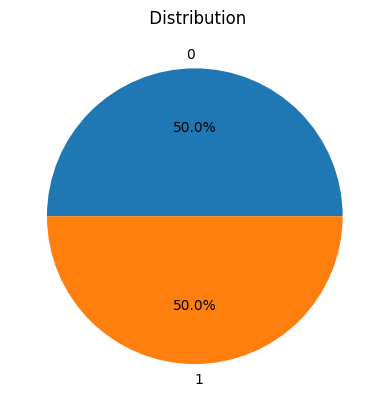

In [ ]:
#distribution of our labels(AI,Human)-no bias
df["label"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title(" Distribution")
plt.ylabel("")
plt.show()

# **1. Preprocessing Tasks**

## Tasks Included

1.1 Missing Values Handling

1.2 Duplicate Handling

1.3 Arabic Text Normalization

1.4 Removing Diacritics

1.5 Removing Numbers

1.6 Tokenization

1.7 Stopwords Removal

1.8 Stemming

1.9 Lemmatization


# ⚠️  Check Missing Values

In [ ]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
source                    0
document_id               0
text                      0
label                     0
generator                 0
category                  0
subcategory               0
token_count               0
text_for_arabert_base     0
text_for_arabert_large    0
text_for_araelectra       0
dtype: int64


In [ ]:

df["text_traditional"] = df["text"]
df["text_bert"] = df["text"]

print(df[["text", "text_traditional", "text_bert"]].head())

                                                text  \
0  عجز الميزانية الأمريكية يرتفع إلى 399 مليار دو...   
1  زيادة عجز الميزانية الأمريكية إلى 399 مليار دو...   
2  الاسترليني يهبط أمام الدولار واليورو وسط شكوك ...   
3  تراجع الجنيه الاسترليني اليوم الاثنين أمام الد...   
4  الحديدة.. قصف حوثي يحرق طعام الجياع داخل مطاحن...   

                                    text_traditional  \
0  عجز الميزانية الأمريكية يرتفع إلى 399 مليار دو...   
1  زيادة عجز الميزانية الأمريكية إلى 399 مليار دو...   
2  الاسترليني يهبط أمام الدولار واليورو وسط شكوك ...   
3  تراجع الجنيه الاسترليني اليوم الاثنين أمام الد...   
4  الحديدة.. قصف حوثي يحرق طعام الجياع داخل مطاحن...   

                                           text_bert  
0  عجز الميزانية الأمريكية يرتفع إلى 399 مليار دو...  
1  زيادة عجز الميزانية الأمريكية إلى 399 مليار دو...  
2  الاسترليني يهبط أمام الدولار واليورو وسط شكوك ...  
3  تراجع الجنيه الاسترليني اليوم الاثنين أمام الد...  
4  الحديدة.. قصف حوثي يحرق طعام الجياع داخل مطاحن..

## Check duplicate rows

In [ ]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
df = df.drop_duplicates()
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# 🔤  Arabic Text Preprocessing

In [ ]:
#normalizing arabic letter

def arabic_normalization(text):
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ؤ", "و", text)
    text = re.sub("ئ", "ي", text)
    text = re.sub("ة", "ه", text)
    text = re.sub("گ", "ك", text)
    return text

df['text_traditional'] = df['text_traditional'].apply(arabic_normalization)
df['text_bert'] = df['text_bert'].apply(arabic_normalization)

print(df[['text_traditional', 'text_bert']].head())

                                    text_traditional  \
0  عجز الميزانيه الامريكيه يرتفع الى 399 مليار دو...   
1  زياده عجز الميزانيه الامريكيه الى 399 مليار دو...   
2  الاسترليني يهبط امام الدولار واليورو وسط شكوك ...   
3  تراجع الجنيه الاسترليني اليوم الاثنين امام الد...   
4  الحديده.. قصف حوثي يحرق طعام الجياع داخل مطاحن...   

                                           text_bert  
0  عجز الميزانيه الامريكيه يرتفع الى 399 مليار دو...  
1  زياده عجز الميزانيه الامريكيه الى 399 مليار دو...  
2  الاسترليني يهبط امام الدولار واليورو وسط شكوك ...  
3  تراجع الجنيه الاسترليني اليوم الاثنين امام الد...  
4  الحديده.. قصف حوثي يحرق طعام الجياع داخل مطاحن...  


In [ ]:


def remove_english(text):
    text = re.sub(r'[A-Za-z]', '', text)
    return text

df['text_traditional'] = df['text_traditional'].apply(remove_english)


In [ ]:


def remove_diacritics(text):
    arabic_diacritics = re.compile("""ّ|َ|ً|ُ|ٌ|ِ|ٍ|ْ|ـ""")
    text = re.sub(arabic_diacritics, '', text)
    return text

df["text_traditional"] = df["text_traditional"].apply(remove_diacritics)


print("\nAfter Removing Diacritics (Traditional ML):")
print(df[["text_traditional", "text_bert"]].head())


After Removing Diacritics (Traditional ML):
                                    text_traditional  \
0  عجز الميزانيه الامريكيه يرتفع الى 399 مليار دو...   
1  زياده عجز الميزانيه الامريكيه الى 399 مليار دو...   
2  الاسترليني يهبط امام الدولار واليورو وسط شكوك ...   
3  تراجع الجنيه الاسترليني اليوم الاثنين امام الد...   
4  الحديده.. قصف حوثي يحرق طعام الجياع داخل مطاحن...   

                                           text_bert  
0  عجز الميزانيه الامريكيه يرتفع الى 399 مليار دو...  
1  زياده عجز الميزانيه الامريكيه الى 399 مليار دو...  
2  الاسترليني يهبط امام الدولار واليورو وسط شكوك ...  
3  تراجع الجنيه الاسترليني اليوم الاثنين امام الد...  
4  الحديده.. قصف حوثي يحرق طعام الجياع داخل مطاحن...  


# ✂️ Text Tokenization

In [ ]:

def tokenize(text):
    return text.split()

df["text_traditional"] = df["text_traditional"].apply(tokenize)

print("\nAfter Tokenization (Traditional ML):")
print(df[["text_traditional"]].head())


After Tokenization (Traditional ML):
                                    text_traditional
0  [عجز, الميزانيه, الامريكيه, يرتفع, الى, 399, م...
1  [زياده, عجز, الميزانيه, الامريكيه, الى, 399, م...
2  [الاسترليني, يهبط, امام, الدولار, واليورو, وسط...
3  [تراجع, الجنيه, الاسترليني, اليوم, الاثنين, ام...
4  [الحديده.., قصف, حوثي, يحرق, طعام, الجياع, داخ...


# 🚫 Remove Stopwords

In [ ]:

arabic_stopwords = set(stopwords.words('arabic'))


def remove_stopwords(tokens):
    return [word for word in tokens if word not in arabic_stopwords]

df["text_traditional"] = df["text_traditional"].apply(remove_stopwords)


print("\nAfter Removing Stopwords (Traditional ML):")
print(df[["text_traditional"]].head())


After Removing Stopwords (Traditional ML):
                                    text_traditional
0  [عجز, الميزانيه, الامريكيه, يرتفع, الى, 399, م...
1  [زياده, عجز, الميزانيه, الامريكيه, الى, 399, م...
2  [الاسترليني, يهبط, امام, الدولار, واليورو, وسط...
3  [تراجع, الجنيه, الاسترليني, اليوم, الاثنين, ام...
4  [الحديده.., قصف, حوثي, يحرق, طعام, الجياع, داخ...


# 🌱 Stemming / Lemmatization

In [ ]:


stemmer = ArabicLightStemmer()

def stem_in_batches(texts, batch_size=500):
    all_results = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        batch_results = []
        for text in batch:

            if isinstance(text, list):
                words = text
            else:
                words = text.split()

            stemmed_words = []
            for w in words:
                stemmer.light_stem(w)
                stemmed_words.append(stemmer.get_stem())

            batch_results.append(" ".join(stemmed_words))
        all_results.extend(batch_results)
    return all_results


df["text_traditional"] = stem_in_batches(df["text_traditional"].tolist(), batch_size=10000)

print(df[["text_traditional", "text_bert"]].head())

100%|██████████| 3/3 [02:43<00:00, 54.59s/it]

                                    text_traditional  \
0  عجز ميزانيه امريكيه رتفع لى 399 مليار قال زار ...   
1  زياد عجز ميزانيه امريكيه لى 399 مليار شهر افاد...   
2  استرلين هبط مام دولار يورو سط شك شان مويل خط ن...   
3  راجع جنيه استرلين يوم اثن مام دولار امريك يورو...   
4  حديده.. قصف حوث حرق طعام جياع داخل مطاح بحر اح...   

                                           text_bert  
0  عجز الميزانيه الامريكيه يرتفع الى 399 مليار دو...  
1  زياده عجز الميزانيه الامريكيه الى 399 مليار دو...  
2  الاسترليني يهبط امام الدولار واليورو وسط شكوك ...  
3  تراجع الجنيه الاسترليني اليوم الاثنين امام الد...  
4  الحديده.. قصف حوثي يحرق طعام الجياع داخل مطاحن...  


In [ ]:

from tashaphyne.stemming import ArabicLightStemmer
from tqdm import tqdm

lemmer = ArabicLightStemmer()


def lemmatize_text(text):
    words = str(text).split()
    lemmas = []
    for w in words:
        lemmer.light_stem(w)
        lemmas.append(lemmer.get_stem())
    return " ".join(lemmas)


def lemmatize_in_batches(texts, batch_size=1000):
    all_results = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i + batch_size]
        batch_results = [lemmatize_text(text) for text in batch]
        all_results.extend(batch_results)
    return all_results

df["text_traditional"] = lemmatize_in_batches(
    df["text_traditional"].astype(str).tolist(),
    batch_size=1000
)


print(df[["text_traditional", "text_bert"]].head())

100%|██████████| 21/21 [00:56<00:00,  2.69s/it]

                                    text_traditional  \
0  عجز ميزان امريك رتفع لى 399 مليار قال زار خزا ...   
1  زياد عجز ميزان امريك لى 399 مليار شهر فاد زار ...   
2  استرل هبط مام دولار ورو سط شك شا مويل خط فاق ه...   
3  راجع جن استرل وم ثن مام دولار مر ورو اوروبي، ت...   
4  حديده.. قصف حوث حرق طعام جياع داخل مطاح حر حمر...   

                                           text_bert  
0  عجز الميزانيه الامريكيه يرتفع الى 399 مليار دو...  
1  زياده عجز الميزانيه الامريكيه الى 399 مليار دو...  
2  الاسترليني يهبط امام الدولار واليورو وسط شكوك ...  
3  تراجع الجنيه الاسترليني اليوم الاثنين امام الد...  
4  الحديده.. قصف حوثي يحرق طعام الجياع داخل مطاحن...  


**Insight:**
Batch processing was used during the stemming and lemmatization stages to improve preprocessing efficiency and reduce execution time. Instead of processing the entire dataset at once, the text data was divided into smaller batches, allowing faster and more optimized text preprocessing for large Arabic datasets.


# **2. Feature Extraction Tasks**

In [ ]:

df['text_traditional'] = df['text_traditional'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
print(df[['text_traditional', 'text_bert']].head())

                                    text_traditional  \
0  عجز ميزان امريك رتفع لى 399 مليار قال زار خزا ...   
1  زياد عجز ميزان امريك لى 399 مليار شهر فاد زار ...   
2  استرل هبط مام دولار ورو سط شك شا مويل خط فاق ه...   
3  راجع جن استرل وم ثن مام دولار مر ورو اوروبي، ت...   
4  حديده.. قصف حوث حرق طعام جياع داخل مطاح حر حمر...   

                                           text_bert  
0  عجز الميزانيه الامريكيه يرتفع الى 399 مليار دو...  
1  زياده عجز الميزانيه الامريكيه الى 399 مليار دو...  
2  الاسترليني يهبط امام الدولار واليورو وسط شكوك ...  
3  تراجع الجنيه الاسترليني اليوم الاثنين امام الد...  
4  الحديده.. قصف حوثي يحرق طعام الجياع داخل مطاحن...  


# 👜 Bag of Words Representation

In [ ]:
texts = df["text_traditional"].astype(str)

bow = CountVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    token_pattern=r'(?u)\b[^\d\W]+\b'
)

X_bow = bow.fit_transform(texts)

print("BoW shape:", X_bow.shape)

words_freq = pd.DataFrame({
    'word': bow.get_feature_names_out(),
    'count': X_bow.sum(axis=0).A1
})
words_freq_sorted = words_freq.sort_values(by='count', ascending=False)

print("Top 20 words:")
print(words_freq_sorted.head(20))

BoW shape: (20268, 5000)
Top 20 words:
      word  count
279     ان  32042
3576    لى  20767
2794   عام   6719
4559    نت   6307
2289    شر   6269
3559    له   6236
1341  خلال   6125
3022   عمل   6055
4652    نه   5921
4231    مك   5604
4255    مل   5518
1030    حد   5307
3910    مر   5092
4876    وم   5000
427     او   4762
816   جديد   4756
656     تم   4691
2512    صل   4674
1869   ريق   4611
4755    هم   4575


# 🧠 TF-IDF Representation

In [ ]:
# Converting text into numbers for Traditional ML
# Initialize the object that performs text analysis and word extraction
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)  # unigrams and bigrams
)

# Convert each text into a vector
X_tfidf = tfidf.fit_transform(df['text_traditional'])

# Print the number of texts and the number of unique words (vocabulary size)
print("TF-IDF shape:", X_tfidf.shape)

# Print top 20 features
print(tfidf.get_feature_names_out()[:20])

TF-IDF shape: (20268, 5000)
['000' '05' '10' '10 مليار' '100' '11' '12' '120' '13' '130' '14' '15'
 '150' '1500' '16' '17' '18' '19' '20' '200']


# 🔡  Word2Vec Representation

In [ ]:
sentences = df['text_traditional'].apply(lambda x: x.split()).tolist()

word2vec_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

print("Word2Vec model trained successfully!")

Word2Vec model trained successfully!


In [ ]:
user_word = input("Enter a word to check: ")

if user_word in word2vec_model.wv:
    count = word2vec_model.wv.get_vecattr(user_word, "count")
    print(f"The word '{user_word}' exists in the dictionary and its occurrence count is: {count}")
else:
    print(f"The word '{user_word}' does not exist in the dictionary.")

Enter a word to check: ابراهيم
The word 'ابراهيم' exists in the dictionary and its occurrence count is: 263


# **3. Modeling Tasks**

# **3.1 Traditional Machine Learning Model**

Naive Bayes

Logistic Regression

Linear SVM



In [ ]:
X_trad = df['text_traditional']
X_tfidf = tfidf.fit_transform(X_trad)

In [ ]:
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.3, random_state=42
)


X_1, X_2, y_1, y_2 = train_test_split(
    X_test, y_test , test_size=1/3, random_state=42
)

# 🤖  Naive Bayes Model + TF-IDF

In [ ]:
#Naive Bayes
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.795592830126624


# 📈  Logistic Regression Model + TF-IDF

In [ ]:
# LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8413089952310475


# ⚡ Support Vector Machine Model SVM + TF-IDF

In [ ]:
# Creating the SVM model
# SVM --> find the best line to separate the classes
svm_model = SVC()

# Train the model using training data
svm_model.fit(X_train, y_train)

# Predict the test data
svm_predictions = svm_model.predict(X_test)

# Calculating accuracy
svm_accuracy = accuracy_score(y_test, svm_predictions)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.8404867620457162


These models use TF-IDF features for Arabic text classification

# 🤖 Transformer-Based Arabic Language Models

* AraBERT v0.2 Base
  (aubmindlab/bert-base-arabertv02)

* MARBERT
  (UBC-NLP/MARBERT)


Dataset Shape: (20268, 2)
label
0    10134
1    10134
Name: count, dtype: int64
Train: (14187,)
Dev: (3040,)
Test: (3041,)
Classes: [0 1]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Micro F1,Weighted F1
1,0.157370,0.343184,0.914474,0.914109,0.914474,0.914109
2,0.106070,0.277420,0.940461,0.940350,0.940461,0.940350
3,0.040552,0.251238,0.949013,0.948959,0.949013,0.948959



AraBERT Development Results:
{'eval_loss': 0.2512379586696625, 'eval_accuracy': 0.9490131578947368, 'eval_macro_f1': 0.9489590273791706, 'eval_micro_f1': 0.9490131578947368, 'eval_weighted_f1': 0.9489590273791706, 'eval_runtime': 6.4514, 'eval_samples_per_second': 471.215, 'eval_steps_per_second': 29.451, 'epoch': 3.0}

AraBERT Test Results:
{'eval_loss': 0.27326831221580505, 'eval_accuracy': 0.9467280499835581, 'eval_macro_f1': 0.9466569792623136, 'eval_micro_f1': 0.9467280499835581, 'eval_weighted_f1': 0.9466563389855455, 'eval_runtime': 6.6814, 'eval_samples_per_second': 455.141, 'eval_steps_per_second': 28.587, 'epoch': 3.0}

AraBERT Accuracy: 0.9467280499835581
AraBERT Macro F1: 0.9466569792623136
AraBERT Weighted F1: 0.9466563389855455

AraBERT Classification Report:

              precision    recall  f1-score   support

       Human       0.98      0.91      0.94      1521
         LLM       0.92      0.98      0.95      1520

    accuracy                           0.95      3

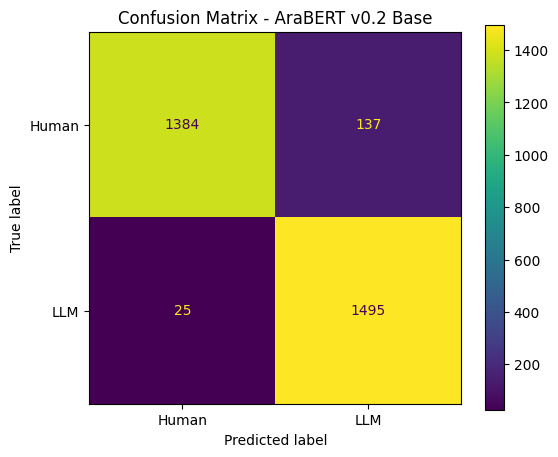

In [ ]:

# ------------------------------
# Use text_bert column for AraBERT
# ------------------------------
df = df[["text_bert", "label"]].dropna()
df["text_bert"] = df["text_bert"].astype(str)
df["label"] = df["label"].astype(int)

print("Dataset Shape:", df.shape)
print(df["label"].value_counts())

# ------------------------------
# Split Data
# ------------------------------
X = df["text_bert"]
y = df["label"]

# Train / temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Dev / Test
X_dev, X_test, y_dev, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape)
print("Dev:", X_dev.shape)
print("Test:", X_test.shape)

# ------------------------------
# Label Encoding
# ------------------------------
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_dev_enc = le.transform(y_dev)
y_test_enc = le.transform(y_test)
print("Classes:", le.classes_)

# ------------------------------
# Load AraBERT v0.2 Base
# ------------------------------
model_name = "aubmindlab/bert-base-arabertv02"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(le.classes_)
)

# ------------------------------
# Dataset Class
# ------------------------------
class ALHDDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=128
        )
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# ------------------------------
# Create Datasets
# ------------------------------
train_dataset = ALHDDataset(X_train, y_train_enc)
dev_dataset = ALHDDataset(X_dev, y_dev_enc)
test_dataset = ALHDDataset(X_test, y_test_enc)

# ------------------------------
# Metrics Function
# ------------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "micro_f1": f1_score(labels, preds, average="micro"),
        "weighted_f1": f1_score(labels, preds, average="weighted")
    }

# ------------------------------
# Training Arguments
# ------------------------------
training_args = TrainingArguments(
    output_dir="./arabert_results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="no",
    report_to="none"
)

# ------------------------------
# Trainer
# ------------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    compute_metrics=compute_metrics
)

# ------------------------------
# Train Model
# ------------------------------
trainer.train()

# ------------------------------
# Evaluate Dev
# ------------------------------
dev_results = trainer.evaluate(dev_dataset)
print("\nAraBERT Development Results:")
print(dev_results)

# ------------------------------
# Evaluate Test
# ------------------------------
arabert_results = trainer.evaluate(test_dataset)
print("\nAraBERT Test Results:")
print(arabert_results)

# ------------------------------
# Save Metrics
# ------------------------------
arabert_accuracy = arabert_results["eval_accuracy"]
arabert_macro_f1 = arabert_results["eval_macro_f1"]
arabert_weighted_f1 = arabert_results["eval_weighted_f1"]

print("\nAraBERT Accuracy:", arabert_accuracy)
print("AraBERT Macro F1:", arabert_macro_f1)
print("AraBERT Weighted F1:", arabert_weighted_f1)

# ------------------------------
# Predictions & Classification Report
# ------------------------------
predictions = trainer.predict(test_dataset)
arabert_preds = np.argmax(predictions.predictions, axis=1)
arabert_labels = predictions.label_ids

print("\nAraBERT Classification Report:\n")
print(
    classification_report(
        arabert_labels,
        arabert_preds,
        target_names=["Human", "LLM"],
        zero_division=0
    )
)

# ------------------------------
# Confusion Matrix
# ------------------------------
cm_arabert = confusion_matrix(arabert_labels, arabert_preds)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_arabert,
    display_labels=["Human", "LLM"]
)
disp.plot(ax=ax)
plt.title("Confusion Matrix - AraBERT v0.2 Base")
plt.show()

Dataset Shape: (20268, 2)
label
0    10134
1    10134
Name: count, dtype: int64
Train: (14187,)
Dev: (3040,)
Test: (3041,)
Classes: [0 1]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on yo

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Micro F1,Weighted F1
1,0.149232,0.473410,0.896053,0.895214,0.896053,0.895214
2,0.114369,0.412849,0.922368,0.922058,0.922368,0.922058
3,0.016125,0.412449,0.935855,0.935721,0.935855,0.935721



MARBERT Development Results:
{'eval_loss': 0.412448525428772, 'eval_accuracy': 0.9358552631578947, 'eval_macro_f1': 0.9357208776702592, 'eval_micro_f1': 0.9358552631578947, 'eval_weighted_f1': 0.9357208776702592, 'eval_runtime': 6.7355, 'eval_samples_per_second': 451.338, 'eval_steps_per_second': 28.209, 'epoch': 3.0}

MARBERT Test Results:
{'eval_loss': 0.4072321951389313, 'eval_accuracy': 0.9385070700427491, 'eval_macro_f1': 0.938397930431661, 'eval_micro_f1': 0.9385070700427491, 'eval_weighted_f1': 0.9383970777784494, 'eval_runtime': 6.8896, 'eval_samples_per_second': 441.387, 'eval_steps_per_second': 27.723, 'epoch': 3.0}

MARBERT Accuracy: 0.9385070700427491
MARBERT Macro F1: 0.938397930431661
MARBERT Weighted F1: 0.9383970777784494

MARBERT Classification Report:

              precision    recall  f1-score   support

       Human       0.98      0.90      0.94      1521
         LLM       0.90      0.98      0.94      1520

    accuracy                           0.94      3041


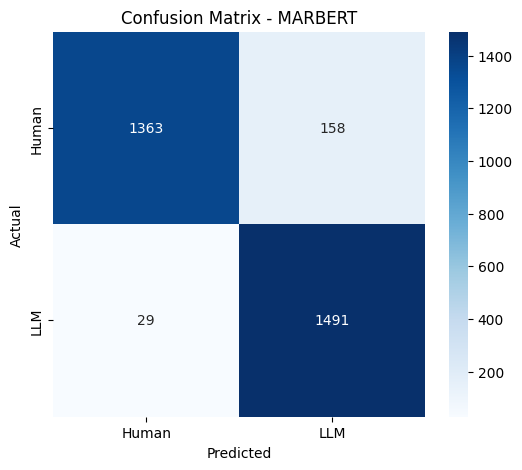

In [ ]:


# ------------------------------
# Use text_bert column for MARBERT
# ------------------------------
df = df[["text_bert", "label"]].dropna()
df["text_bert"] = df["text_bert"].astype(str)
df["label"] = df["label"].astype(int)

print("Dataset Shape:", df.shape)
print(df["label"].value_counts())

# ------------------------------
# Split Data
# ------------------------------
X = df["text_bert"]
y = df["label"]

# Train / temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Dev / Test
X_dev, X_test, y_dev, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape)
print("Dev:", X_dev.shape)
print("Test:", X_test.shape)

# ------------------------------
# Label Encoding
# ------------------------------
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_dev_enc = le.transform(y_dev)
y_test_enc = le.transform(y_test)
print("Classes:", le.classes_)

# ------------------------------
# Load MARBERT
# ------------------------------
model_name = "UBC-NLP/MARBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(le.classes_)
)

# ------------------------------
# Dataset Class
# ------------------------------
class ALHDDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=128
        )
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# ------------------------------
# Create Datasets
# ------------------------------
train_dataset = ALHDDataset(X_train, y_train_enc)
dev_dataset = ALHDDataset(X_dev, y_dev_enc)
test_dataset = ALHDDataset(X_test, y_test_enc)

# ------------------------------
# Metrics Function
# ------------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "micro_f1": f1_score(labels, preds, average="micro"),
        "weighted_f1": f1_score(labels, preds, average="weighted")
    }

# ------------------------------
# Training Arguments
# ------------------------------
training_args = TrainingArguments(
    output_dir="./marbert_results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="no",
    report_to="none"
)

# ------------------------------
# Trainer
# ------------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    compute_metrics=compute_metrics
)

# ------------------------------
# Train Model
# ------------------------------
trainer.train()

# ------------------------------
# Evaluate Dev
# ------------------------------
dev_results = trainer.evaluate(dev_dataset)
print("\nMARBERT Development Results:")
print(dev_results)

# ------------------------------
# Evaluate Test
# ------------------------------
marbert_results = trainer.evaluate(test_dataset)
print("\nMARBERT Test Results:")
print(marbert_results)

# ------------------------------
# Save Metrics
# ------------------------------
marbert_accuracy = marbert_results["eval_accuracy"]
marbert_macro_f1 = marbert_results["eval_macro_f1"]
marbert_weighted_f1 = marbert_results["eval_weighted_f1"]

print("\nMARBERT Accuracy:", marbert_accuracy)
print("MARBERT Macro F1:", marbert_macro_f1)
print("MARBERT Weighted F1:", marbert_weighted_f1)

# ------------------------------
# Predictions & Classification Report
# ------------------------------
predictions = trainer.predict(test_dataset)
marbert_preds = np.argmax(predictions.predictions, axis=1)
marbert_labels = predictions.label_ids

print("\nMARBERT Classification Report:\n")
print(
    classification_report(
        marbert_labels,
        marbert_preds,
        target_names=["Human", "LLM"],
        zero_division=0
    )
)

# ------------------------------
# Confusion Matrix
# ------------------------------
cm_marbert = confusion_matrix(marbert_labels, marbert_preds)
print("\nMARBERT Confusion Matrix:")
print(cm_marbert)

# ------------------------------
# Confusion Matrix Visualization
# ------------------------------
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_marbert,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Human", "LLM"],
    yticklabels=["Human", "LLM"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - MARBERT")
plt.show()

# **📋Evaluation**

# 🤖 Traditional ML Evaluation

In [ ]:
# Predict using test data only

y_pred_nb = nb_model.predict(X_2)
y_pred_svm = svm_model.predict(X_2)


In [ ]:
print("Naive Bayes Macro F1:")
print(f1_score(y_2, y_pred_nb, average="macro"))
print(classification_report(y_2, y_pred_nb, target_names=["Human", "LLM"]))
print(confusion_matrix(y_2, y_pred_nb))

Naive Bayes Macro F1:
0.8025759716098284
              precision    recall  f1-score   support

       Human       0.79      0.83      0.81      1041
         LLM       0.82      0.77      0.79       986

    accuracy                           0.80      2027
   macro avg       0.80      0.80      0.80      2027
weighted avg       0.80      0.80      0.80      2027

[[869 172]
 [227 759]]


In [ ]:
print("SVM Macro F1:")
print(f1_score(y_2, y_pred_svm, average="macro"))

print(classification_report(y_2, y_pred_svm, target_names=["Human", "LLM"]))

print(confusion_matrix(y_2, y_pred_svm))

SVM Macro F1:
0.8228721202251097
              precision    recall  f1-score   support

       Human       0.81      0.85      0.83      1041
         LLM       0.84      0.79      0.81       986

    accuracy                           0.82      2027
   macro avg       0.82      0.82      0.82      2027
weighted avg       0.82      0.82      0.82      2027

[[889 152]
 [206 780]]


In [ ]:

lr_model = LogisticRegression()

lr_model.fit(X_1, y_1)

LogisticRegression()

In [ ]:
# Logistic Regression Predictions
y_pred_lr = lr_model.predict(X_2)

# Weighted F1
f1_lr = f1_score(
    y_2,
    y_pred_lr,
    average="weighted"
)

print("Logistic Regression Weighted F1:")
print(f1_lr)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_2,
        y_pred_lr,
        target_names=["Human", "LLM"]
    )
)

# Confusion Matrix
print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_2,
        y_pred_lr
    )
)

Logistic Regression Weighted F1:
0.7922130762667053

Classification Report:
              precision    recall  f1-score   support

       Human       0.79      0.81      0.80      1041
         LLM       0.79      0.77      0.78       986

    accuracy                           0.79      2027
   macro avg       0.79      0.79      0.79      2027
weighted avg       0.79      0.79      0.79      2027


Confusion Matrix:
[[842 199]
 [222 764]]


# 📊 Model Comparison

In [ ]:
nb_f1 = f1_score(y_2, y_pred_nb, average="weighted")

lr_f1 = f1_score(y_2, y_pred_lr, average="weighted")

svm_f1 = f1_score(y_2, y_pred_svm, average="weighted")

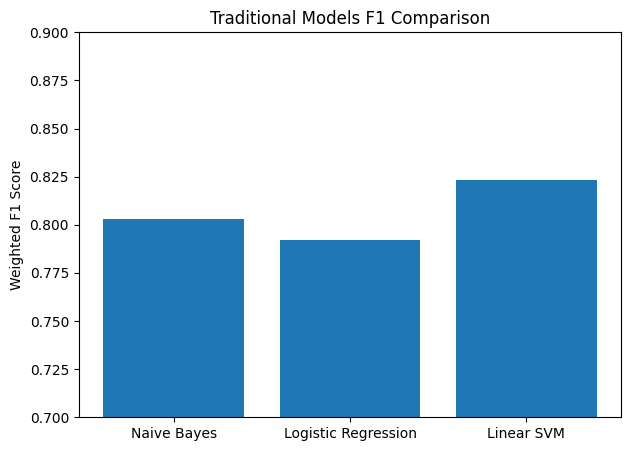

In [ ]:
models = ["Naive Bayes", "Logistic Regression", "Linear SVM"]

f1_scores = [nb_f1, lr_f1, svm_f1]

plt.figure(figsize=(7,5))

plt.bar(models, f1_scores)

plt.title("Traditional Models F1 Comparison")

plt.ylabel("Weighted F1 Score")

plt.ylim(0.7, 0.9)

plt.show()



---

📊 **Traditional ML vs Transformer Models Comparison**
| Model                        | Accuracy | Macro F1 | Weighted F1 |
| ---------------------------- | -------- | -------- | ----------- |
| Naive Bayes + TF-IDF         | 79.56%   | 80.26%   | 80.00%      |
| Logistic Regression + TF-IDF | 84.13%   | 79.00%   | 79.22%      |
| SVM + TF-IDF                 | 84.05%   | 82.29%   | 82.00%      |
| AraBERT v0.2 Base            | 94.64%   | —        | 94.63%      |
| MARBERT                      | 93.85%   | —        | 93.84%      |


🔍 **Performance Comparison Analysis**

* The experimental results show that **Transformer-based models** achieved substantially better performance than traditional machine learning methods in distinguishing Human-written Arabic text from AI-generated text.

* Within the traditional machine learning approaches, **SVM with TF-IDF features** produced the strongest results, achieving:

  * Accuracy = 84.05%
  * Weighted F1-score = 82.00%

  This indicates that SVM was more effective in capturing discriminative Arabic linguistic patterns compared to Naive Bayes and Logistic Regression.

* The deep learning Transformer models demonstrated the highest overall effectiveness, with AraBERT slightly outperforming MARBERT:

  * AraBERT Accuracy = 94.64%

  * Weighted F1 = 94.63%

  * MARBERT Accuracy = 93.85%

  * Weighted F1 = 93.84%

* The superior performance of the Transformer-based models can be explained by several factors:

  1. Using the original Arabic text (`text_bert`) without aggressive preprocessing such as stemming, lemmatization, or stopword removal, which preserved semantic and contextual information.

  2. Leveraging contextual embeddings that better understand Arabic sentence structure and meaning.

  3. Applying balanced Train/Development/Test splits, ensuring stable and fair evaluation across all classes.

  4. Fine-tuning the models for 3 epochs with an appropriate batch size, allowing efficient adaptation to the Arabic AI-text detection task.

* Overall, the results confirm that Arabic Transformer architectures are highly effective for AI-generated text detection, significantly outperforming traditional feature-engineering approaches in both accuracy and robustness.

